# Teil 2 - Datenbeschreibung

Dieses Notebook dokumentiert **nur Teil 2** der Leistungsbeurteilung. Der Datensatz `Smartphone_Usage_Productivity_Dataset_50000.csv` wird eingelesen, kurz fuer die programmatische Verarbeitung vorbereitet und anhand der geforderten Punkte 2.1 bis 2.4 beschrieben.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

dataset_path = 'Smartphone_Usage_Productivity_Dataset_50000.csv'
df = pd.read_csv(dataset_path, sep=';')

print(f'Zeilen: {len(df)}')
print(f'Spalten: {df.shape[1]}')
df.head()

Zeilen: 50000
Spalten: 13


,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.30,6.70,6,8.80,4,42,1,8.70
1,U2,25,Male,Professional,Android,1.20,1.50,5,6.40,1,51,3,5.10
2,U3,19,Male,Student,iOS,5.30,5.70,5,9.00,4,14,5,6.30
3,U4,35,Female,Business Owner,iOS,5.80,2.50,2,5.70,3,36,6,12.80
4,U5,33,Male,Freelancer,Android,7.90,1.30,4,5.70,3,37,5,9.90


## 2.1 Zielvariable fuer Vorhersagen

Ich moechte das Feld **`Work_Productivity_Score`** vorhersagen. Dieses Feld ist fuer das Projekt am interessantesten, weil es direkt beschreibt, wie produktiv eine Person in Abhaengigkeit von mehreren anderen Merkmalen ist. Die uebrigen Felder wie Alter, Geraetetyp, taegliche Handyzeit, Social-Media-Nutzung, Schlaf oder Koffeinkonsum koennen als moegliche Einflussgroessen dienen. Das Feld `User_ID` ist hingegen nur ein Identifikator und soll spaeter nicht als Modellmerkmal verwendet werden.

In [2]:
target_column = 'Work_Productivity_Score'
numeric_columns = df.select_dtypes(include='number').columns.tolist()
categorical_columns = df.select_dtypes(exclude='number').columns.tolist()

print('Zielvariable:', target_column)
print('Numerische Felder:', numeric_columns)
print('Kategoriale Felder:', categorical_columns)

df[target_column].value_counts().sort_index().rename('Anzahl')

Zielvariable: Work_Productivity_Score
Numerische Felder: ['Age', 'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level', 'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours']
Kategoriale Felder: ['User_ID', 'Gender', 'Occupation', 'Device_Type']


Work_Productivity_Score
1     4974
2     5077
3     4909
4     4961
5     5079
6     5074
7     4938
8     4835
9     5126
10    5027
Name: Anzahl, dtype: int64

## 2.2 Statistische Informationen zu allen Feldern

Zuerst erstelle ich eine kompakte Uebersicht ueber **alle** Felder. Fuer numerische Felder berechne ich Mittelwert, Median, Standardabweichung, Minimum und Maximum. Fuer kategoriale Felder sind vor allem Datentyp, Anzahl eindeutiger Werte und der Modus relevant.

In [3]:
summary_rows = []

for column in df.columns:
    series = df[column]
    row = {
        'Feld': column,
        'Datentyp': str(series.dtype),
        'Fehlende_Werte': int(series.isna().sum()),
        'Eindeutige_Werte': int(series.nunique(dropna=False)),
        'Modus': series.mode(dropna=False).iat[0],
    }

    if pd.api.types.is_numeric_dtype(series):
        row.update({
            'Mittelwert': round(float(series.mean()), 2),
            'Median': round(float(series.median()), 2),
            'Standardabweichung': round(float(series.std()), 2),
            'Minimum': round(float(series.min()), 2),
            'Maximum': round(float(series.max()), 2),
        })
    else:
        row.update({
            'Mittelwert': None,
            'Median': None,
            'Standardabweichung': None,
            'Minimum': None,
            'Maximum': None,
        })

    summary_rows.append(row)

field_overview = pd.DataFrame(summary_rows)
field_overview

,Feld,Datentyp,Fehlende_Werte,Eindeutige_Werte,Modus,Mittelwert,Median,Standardabweichung,Minimum,Maximum
0,User_ID,str,0,50000,U1,NaN,NaN,NaN,NaN,NaN
1,Age,int64,0,43,54,39.03,39.00,12.41,18.00,60.00
2,Gender,str,0,3,Male,NaN,NaN,NaN,NaN,NaN
3,Occupation,str,0,4,Professional,NaN,NaN,NaN,NaN,NaN
4,Device_Type,str,0,2,Android,NaN,NaN,NaN,NaN,NaN
5,Daily_Phone_Hours,float64,0,111,6.30,6.51,6.50,3.17,1.00,12.00
6,Social_Media_Hours,float64,0,76,5.60,4.27,4.30,2.16,0.50,8.00
7,Work_Productivity_Score,int64,0,10,9,5.50,5.50,2.87,1.00,10.00
8,Sleep_Hours,float64,0,51,5.00,6.50,6.50,1.45,4.00,9.00
9,Stress_Level,int64,0,10,5,5.50,6.00,2.87,1.00,10.00


In [4]:
numeric_summary = (
    df[numeric_columns]
    .describe()
    .T[['mean', '50%', 'std', 'min', 'max']]
    .rename(columns={
        'mean': 'Mittelwert',
        '50%': 'Median',
        'std': 'Standardabweichung',
        'min': 'Minimum',
        'max': 'Maximum',
    })
    .round(2)
)

numeric_summary

,Mittelwert,Median,Standardabweichung,Minimum,Maximum
Age,39.03,39.00,12.41,18.00,60.00
Daily_Phone_Hours,6.51,6.50,3.17,1.00,12.00
Social_Media_Hours,4.27,4.30,2.16,0.50,8.00
Work_Productivity_Score,5.50,5.50,2.87,1.00,10.00
Sleep_Hours,6.50,6.50,1.45,4.00,9.00
Stress_Level,5.50,6.00,2.87,1.00,10.00
App_Usage_Count,32.44,32.00,16.12,5.00,60.00
Caffeine_Intake_Cups,3.00,3.00,2.00,0.00,6.00
Weekend_Screen_Time_Hours,8.01,8.00,3.46,2.00,14.00


## Vorbereitung fuer die programmatische Verarbeitung

Der Datensatz enthaelt keine fehlenden Werte. Fuer die spaetere Modellierung erstelle ich dennoch eine bereinigte Variante `df_model_ready`. Dabei wird `User_ID` entfernt, weil dieses Feld nur eine Kennung ist und keine sinnvolle Information fuer ein Modell liefert. Kategoriale Felder bleiben vorerst erhalten und koennen in Teil 3 bei Bedarf codiert werden.

In [5]:
missing_values = df.isna().sum().rename('Fehlende_Werte').to_frame()
print(missing_values.T)

df_model_ready = df.drop(columns=['User_ID']).copy()
print('Form fuer die weitere Verarbeitung:', df_model_ready.shape)
df_model_ready.head()

                User_ID  Age  Gender  Occupation  Device_Type  \
Fehlende_Werte        0    0       0           0            0   

                Daily_Phone_Hours  Social_Media_Hours  \
Fehlende_Werte                  0                   0   

                Work_Productivity_Score  Sleep_Hours  Stress_Level  \
Fehlende_Werte                        0            0             0   

                App_Usage_Count  Caffeine_Intake_Cups  \
Fehlende_Werte                0                     0   

                Weekend_Screen_Time_Hours  
Fehlende_Werte                          0  
Form fuer die weitere Verarbeitung: (50000, 12)


,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,58,Male,Professional,Android,1.30,6.70,6,8.80,4,42,1,8.70
1,25,Male,Professional,Android,1.20,1.50,5,6.40,1,51,3,5.10
2,19,Male,Student,iOS,5.30,5.70,5,9.00,4,14,5,6.30
3,35,Female,Business Owner,iOS,5.80,2.50,2,5.70,3,36,6,12.80
4,33,Male,Freelancer,Android,7.90,1.30,4,5.70,3,37,5,9.90


## 2.3 Grafik

Die folgende Abbildung zeigt einerseits die Verteilung der taeglichen Smartphone-Nutzung und andererseits einen Regressionsplot zwischen taeglicher Smartphone-Nutzung und Produktivitaet. So ist sowohl die Verteilung eines Einzelfelds als auch ein moeglicher Zusammenhang zwischen zwei Feldern sichtbar.

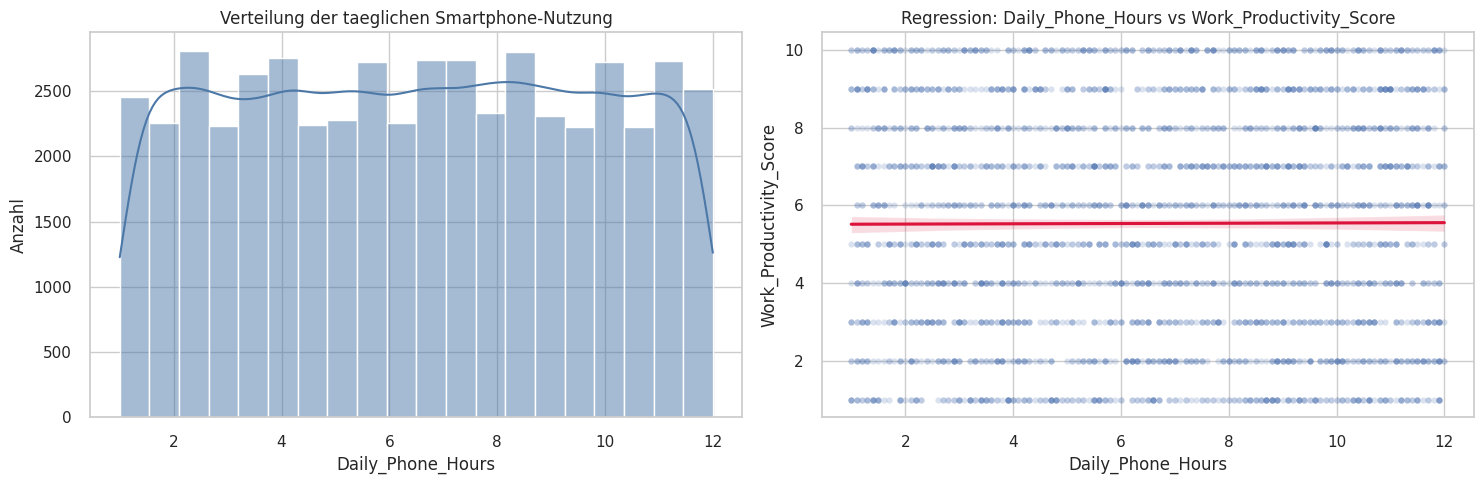

In [6]:
sns.set_theme(style='whitegrid')
sample = df.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Daily_Phone_Hours'], bins=20, kde=True, color='#4C78A8', ax=axes[0])
axes[0].set_title('Verteilung der taeglichen Smartphone-Nutzung')
axes[0].set_xlabel('Daily_Phone_Hours')
axes[0].set_ylabel('Anzahl')

sns.regplot(
    data=sample,
    x='Daily_Phone_Hours',
    y='Work_Productivity_Score',
    scatter_kws={'alpha': 0.20, 's': 20},
    line_kws={'color': 'crimson'},
    ax=axes[1],
)
axes[1].set_title('Regression: Daily_Phone_Hours vs Work_Productivity_Score')
axes[1].set_xlabel('Daily_Phone_Hours')
axes[1].set_ylabel('Work_Productivity_Score')

plt.tight_layout()
plt.show()

## 2.4 Skalierung eines Datenfelds

Ich skaliere das numerische Feld **`Daily_Phone_Hours`** mit dem `MinMaxScaler`. Dabei werden alle Werte auf einen Bereich zwischen **0 und 1** normalisiert. Diese Form der Skalierung ist gut nachvollziehbar und fuer viele spaetere ML-Verfahren sinnvoll, weil alle Werte im selben Zahlenbereich liegen und dadurch leichter miteinander verglichen werden koennen.

In [7]:
scaler = MinMaxScaler()
df_model_ready['Daily_Phone_Hours_Scaled'] = scaler.fit_transform(df_model_ready[['Daily_Phone_Hours']])

scaling_comparison = pd.DataFrame({
    'Kennzahl': ['Mittelwert', 'Standardabweichung', 'Minimum', 'Maximum'],
    'Original': [
        df_model_ready['Daily_Phone_Hours'].mean(),
        df_model_ready['Daily_Phone_Hours'].std(ddof=0),
        df_model_ready['Daily_Phone_Hours'].min(),
        df_model_ready['Daily_Phone_Hours'].max(),
    ],
    'Skaliert': [
        df_model_ready['Daily_Phone_Hours_Scaled'].mean(),
        df_model_ready['Daily_Phone_Hours_Scaled'].std(ddof=0),
        df_model_ready['Daily_Phone_Hours_Scaled'].min(),
        df_model_ready['Daily_Phone_Hours_Scaled'].max(),
    ],
}).round(3)

scaling_comparison

,Kennzahl,Original,Skaliert
0,Mittelwert,6.51,0.50
1,Standardabweichung,3.17,0.29
2,Minimum,1.00,0.00
3,Maximum,12.00,1.00


In [8]:
df_model_ready[['Daily_Phone_Hours', 'Daily_Phone_Hours_Scaled']].head(10)

,Daily_Phone_Hours,Daily_Phone_Hours_Scaled
0,1.30,0.03
1,1.20,0.02
2,5.30,0.39
3,5.80,0.44
4,7.90,0.63
5,10.90,0.90
6,5.60,0.42
7,8.50,0.68
8,9.40,0.76
9,2.80,0.16


## Kurzfazit

Fuer Teil 2 wurde das Vorhersagefeld `Work_Productivity_Score` ausgewaehlt, der Datensatz statistisch beschrieben, grafisch untersucht und fuer die weitere Verarbeitung vorbereitet. Das Feld `Daily_Phone_Hours` wurde auf einen Wertebereich von 0 bis 1 skaliert. Damit ist die Grundlage fuer den naechsten Schritt der Modellierung vorhanden.